# Transcript Cleaning Pipeline 
## Isolated into one notebook
### Built based upon McCray Metadata


In [36]:
import pandas as pd
import numpy as np
import re, ast, json, csv
from utils.constants import Paths
from utils.ocr_cleaning import OCR_Clean, OCR_Check
import nltk
from nltk.corpus import words, PlaintextCorpusReader

### Get original metadata

In [37]:
# Get original metadata
dataset = "mccray"
mccray = pd.read_csv(r"../data/mccray/original_data/McCray metadata.csv")
print(list(mccray))

def save_csv(df, title):
    df.to_csv(title,
          index=False,
          encoding='utf-8',
          quoting=csv.QUOTE_NONNUMERIC,   
          escapechar='\\',
          lineterminator='\n')

# # # nltk download
# # nltk.download('words')
# english_vocab = set(w.lower() for w in words.words())

wordlists = PlaintextCorpusReader('../data/mccray', 'combined_words_corpus.txt')

print(len(mccray))

['Title', 'Creator', 'Contributors', 'Date', 'Approximate Date', 'Source', 'Subject', 'Local Subject', 'S.C. County', 'Description', 'Extent', 'Digital Collection', 'Website', 'Contributing Institution', 'Rights', 'Time Period', 'Geographic Location', 'Language', 'Digitization Specifications', 'Date Digital', 'Type', 'Format', 'Media Type', 'Identifier', 'Note', 'Digital Assistant', 'Transcript', 'OCLC number', 'Date created', 'Date modified', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'CONTENTdm file path']
19329


### Handle the fields / basic standardization

In [38]:
# Add 'Year' field
mccray['Year'] = mccray['Date']
mccray['Year'] = mccray['Year'].apply(lambda x: str(x))
mccray['Year'] = mccray['Year'].apply(lambda x: re.sub(r'[^0-9]+', "", x))
mccray['Year'] = mccray['Year'].apply(lambda x: x[:4])

# Copy "Transcript" Column as "Original Transcript" & Remove "Transcript" Column
mccray['Original Transcript'] = mccray['Transcript'] 
mccray = mccray.drop('Transcript', axis=1)  

# Replace empty transcripts with na
mccray['Original Transcript'] = mccray['Original Transcript'].fillna('').apply(lambda x: x.strip() if isinstance(x, str) else '')

# Add "Original Len" Column for lengths
mccray['Original Len'] = mccray['Original Transcript'].str.replace(r'\s+', '', regex=True).str.len()

### Determining messiness and provide details on transcripts

In [39]:
# Helper to find sequences using regex pattern, allowing for exceptions (created for some patterers in OCR_Clean class)
def find_sequences(pattern, text, exceptions=[]):
    candidates = re.findall(pattern, str(text))
    flagged = []
    for candidate in candidates:
        if not any(re.match(exc, candidate) for exc in exceptions):
            flagged.append(candidate)
    return flagged

# Updated data cleaning metrics with new structure
transcript_col = 'Original Transcript'

# Individual pattern detection (Boolean columns)
mccray['Special Pattern'] = mccray[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.special_pattern, x)) > 0)
mccray['General Pattern'] = mccray[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.general_pattern, x, OCR_Clean.general_exceptions)) > 0)
mccray['Repeat Chars'] = mccray[transcript_col].apply(lambda x: len(find_sequences(OCR_Clean.letter_pattern, x)) > 0)
mccray['Short/No Transcript'] = mccray['Original Len'] < 20

# Overall messiness/quaility indicator
mccray['Quality'] = ~(mccray['Special Pattern'] | mccray['General Pattern'] | mccray['Repeat Chars'] | mccray['Short/No Transcript'])

# Issue Types (List of Strings)
def get_issue_types(row):
    types = []
    if row['Special Pattern']:
        types.append('Special Char Artifacts')
    if row['General Pattern']:
        types.append('General Artifacts')
    if row['Repeat Chars']:
        types.append('Repeat Chars')
    if row['Original Len'] == 0:
        types.append('Empty Transcript')
    elif row['Short/No Transcript']:
        types.append('Low Char Count')
    return types

mccray['Issue Types'] = mccray.apply(get_issue_types, axis=1)

# Detected Artifacts (List of Strings)
def get_detected_artifacts(text):
    artifacts = []
    # Add special pattern artifacts
    artifacts.extend(find_sequences(OCR_Clean.special_pattern, text))
    # Add general pattern artifacts
    artifacts.extend(find_sequences(OCR_Clean.general_pattern, text, OCR_Clean.general_exceptions))
    # Add repeat character sequences
    artifacts.extend(find_sequences(OCR_Clean.letter_pattern, text))
    return artifacts

mccray['Detected Artifacts'] = mccray[transcript_col].apply(get_detected_artifacts)

# Data Isolations
## get empty and repeat transcripts

In [40]:
print(list(mccray), "\n")

# Remove [].cpd documents (previously captured by empty docs, but this covers clear seperation / reason behind empty transcripts)
mccray_cpd = mccray[mccray['CONTENTdm file name'].str.split('.').str[1] == 'cpd']
mccray_jp2 = mccray[mccray['CONTENTdm file name'].str.split('.').str[1] != 'cpd']

# Remove empty documents (where Original Transcript is empty or NaN)
mccray_pure_empty = mccray_jp2[mccray_jp2['Original Transcript'].isna() | (mccray_jp2['Original Transcript'].str.strip() == '')]
mccray_no_empty = mccray_jp2[mccray_jp2['Original Transcript'].notna() & (mccray_jp2['Original Transcript'].str.strip() != '')]

# Remove repeated documents (same Original Transcript content, different IDs)
# Keep first occurrence of each unique transcript
mccray_repeated = mccray_no_empty[mccray_no_empty.duplicated(subset=['Original Transcript'], keep=False)]
mccray_no_repeat = mccray_no_empty.drop_duplicates(subset=['Original Transcript'], keep='first')


['Title', 'Creator', 'Contributors', 'Date', 'Approximate Date', 'Source', 'Subject', 'Local Subject', 'S.C. County', 'Description', 'Extent', 'Digital Collection', 'Website', 'Contributing Institution', 'Rights', 'Time Period', 'Geographic Location', 'Language', 'Digitization Specifications', 'Date Digital', 'Type', 'Format', 'Media Type', 'Identifier', 'Note', 'Digital Assistant', 'OCLC number', 'Date created', 'Date modified', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'CONTENTdm file path', 'Year', 'Original Transcript', 'Original Len', 'Special Pattern', 'General Pattern', 'Repeat Chars', 'Short/No Transcript', 'Quality', 'Issue Types', 'Detected Artifacts'] 



In [ ]:
# print counts of inital isolations
print(f'cpd count: {len(mccray_cpd)} / {len(mccray)} -- {len(mccray_cpd)} docs are "cpd" / collections')
print(f'Empty count: {len(mccray_pure_empty)} / {len(mccray)} -- {len(mccray_pure_empty)} docs need rescanned due null content')
print(f'Repeated count: {len(mccray_repeated)} / {len(mccray_no_empty)} -- {len(mccray_repeated)} docs need are not needed due to being repeated content') 

# save empty and repeated
save_csv(mccray_cpd, f"../data/{dataset}/split_data/h1_split/D_{dataset[0:2]}_cpd.csv")
save_csv(mccray_pure_empty, f"../data/{dataset}/split_data/h1_split/D_{dataset[0:2]}_0.csv")
save_csv(mccray_repeated, f"../data/{dataset}/split_data/h1_split/D_{dataset[0:2]}_rep.csv")

mccray = mccray_no_repeat.copy()

cpd count: 303 / 19329 -- 303 docs are "cpd" / collections
Empty count: 4385 / 19329 -- 4385 docs need rescanned due null content
Repeated count: 390 / 14641 -- 390 docs need are not needed due to being repeated content


In [42]:
# Save all OG Transcripts w/ Quality=True to 'Semi-clean Transcripts'
sc_v1_col = 'D_mcc_cleaned_v1'
sc_v2_col = 'D_mcc_cleaned_v2'

### Pre proccessing to turn OG transcripts w/ issues into semi-clean transcripts
#### V1 cleaning first

In [43]:
# Save all OG Transcripts w/ Quality=True to 'Semi-clean Transcripts'
mccray[sc_v1_col] = mccray['Original Transcript'].where(mccray['Quality'] == True, "") 

mccray['Cleaning'] = mccray['Original Transcript'].where(
	(mccray['Quality'] == False) & (mccray['Short/No Transcript'] == False), ""
).astype(str)

# Pattern removal and condence patterns for semi-cleaning
mccray['Cleaning'] = mccray['Cleaning'].apply(lambda x: re.sub(OCR_Clean.letter_pattern, '\\1', x))
mccray['Cleaning'] = mccray['Cleaning'].apply(lambda x: re.sub(OCR_Clean.special_pattern, "", x))
mccray['Cleaning'] = mccray['Cleaning'].apply(lambda x: re.sub(OCR_Clean.general_pattern, "", x))

# Combine the columns which were the most clean, and placed in semi-clean, with the newly 'Cleaning' column
mccray[sc_v1_col] = mccray.apply(
    lambda r: r['Original Transcript']
        if (pd.notna(r['Original Transcript']) and r.get('Quality', False))
        else (r['Cleaning'] if str(r.get('Cleaning','')).strip() != '' else r['Original Transcript']),
    axis=1
).astype(str)

mccray = mccray.drop('Cleaning', axis=1)

# Regex pattern for this:
# To remove ^ and ^+shortphrases, and remove standalone punctuation not attached to words/numbers.

# \^(\w{0,4})   matches ^ followed by 0–4 word characters (short phrases like ^a, ^ok, ^xyz, ,^fele or just ^)
# |             OR
# (?<!\w)       negative lookbehind: ensures the char before is NOT a word character
# [^\w\s]      matches any single character that is NOT a word char and NOT whitespace and not $ % &
# (?!\w)        negative lookahead: ensures the char after is NOT a word character

p1 = r"\^(\w{0,4})|(?<!\w)[^\w\s](?!\w)"

mccray[sc_v1_col] = mccray[sc_v1_col].apply(lambda x: re.sub(p1, "", x))

# Clean spacing (with auto newlining)
def normalize_spaces(text):
	return re.sub(r" {2,}", lambda m: "\n" if len(m.group(0)) > 3 else " ", text)

mccray[sc_v1_col] = mccray[sc_v1_col].apply(normalize_spaces)

mccray['sc_v1_len'] = mccray[sc_v1_col].str.replace(r'\s+', '', regex=True).str.len()


### V2 cleaning, more simple, only pattern removal

In [44]:
mccray[sc_v2_col] = mccray['Original Transcript'].copy()


# Only clean special pattern
mccray[sc_v2_col] = mccray[sc_v2_col].apply(lambda x: re.sub(OCR_Clean.non_ascii, "", x))
mccray[sc_v2_col] = mccray[sc_v2_col].apply(lambda x: re.sub(OCR_Clean.special_pattern_expanded, "", x))
mccray[sc_v2_col] = mccray[sc_v2_col].apply(lambda x: re.sub(OCR_Clean.letter_pattern_4, '\\1', x))
compiled_patterns = OCR_Clean.compile()
mccray[sc_v2_col] = mccray[sc_v2_col].apply(lambda x: OCR_Clean.clean_ocr_text(x, compiled_patterns))


# Clean spacing (with auto newlining)
def normalize_spaces(text):
    return re.sub(r" {2,}", lambda m: "\n" if len(m.group(0)) > 3 else " ", text)

mccray[sc_v2_col] = mccray[sc_v2_col].apply(normalize_spaces)

mccray['sc_v2_len'] = mccray[sc_v2_col].str.replace(r'\s+', '', regex=True).str.len()


In [ ]:

display(mccray[mccray["Title"] == 'Card, 1959 December 22, A Christmas Card from the Northrop Family, page 3'])
print(mccray[mccray["Title"] == 'Card, 1959 December 22, A Christmas Card from the Northrop Family, page 3'])
save_csv(mccray, f"../data/{dataset}/split_data/h1_split/D_{dataset[0:2]}_h1_main.csv")

mccray


,Title,Creator,Contributors,Date,Approximate Date,Source,Subject,Local Subject,S.C. County,Description,...,General Pattern,Repeat Chars,Short/No Transcript,Quality,Issue Types,Detected Artifacts,D_mcc_cleaned_v1,sc_v1_len,D_mcc_cleaned_v2,sc_v2_len
12317,"Card, 1959 December 22, A Christmas Card from ...",NaN,NaN,1959-12-22 00:00:00,NaN,"Manuscripts Annex, Letter size papers, 1929-19...","McCray, John Henry, 1910-1987",NaN,NaN,Christmas card from Northrop Family,...,False,False,True,False,[Low Char Count],[],Made in U. S. A.,12,Made in U. S. A.,12


                                                   Title Creator Contributors  \
12317  Card, 1959 December 22, A Christmas Card from ...     NaN          NaN   

                      Date Approximate Date  \
12317  1959-12-22 00:00:00              NaN   

                                                  Source  \
12317  Manuscripts Annex, Letter size papers, 1929-19...   

                             Subject Local Subject S.C. County  \
12317  McCray, John Henry, 1910-1987           NaN         NaN   

                               Description  ... General Pattern Repeat Chars  \
12317  Christmas card from Northrop Family  ...           False        False   

      Short/No Transcript Quality       Issue Types Detected Artifacts  \
12317                True   False  [Low Char Count]                 []   

       D_mcc_cleaned_v1 sc_v1_len  D_mcc_cleaned_v2 sc_v2_len  
12317  Made in U. S. A.        12  Made in U. S. A.        12  

[1 rows x 47 columns]


,Title,Creator,Contributors,Date,Approximate Date,Source,Subject,Local Subject,S.C. County,Description,...,General Pattern,Repeat Chars,Short/No Transcript,Quality,Issue Types,Detected Artifacts,D_mcc_cleaned_v1,sc_v1_len,D_mcc_cleaned_v2,sc_v2_len
0,Afro-American Newsboy Application signed by Mr...,NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,An application to be a Newsboy for the Afro-Am...,...,False,False,False,True,[],[],-5491 AFRO-AMERICAN NEWSBOY'S APPLICATION I he...,213,-5491 AFRO-AMERICAN NEWSBOY'S APPLICATION I he...,213
1,Lighthouse Informer receipt,NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,A blank Lighthouse and Informer receipt.,...,False,False,False,True,[],[],"19 Received from RECEIVED OF ""Shedding Light F...",119,"19 Received from RECEIVED OF ""Shedding Light F...",121
2,"The Lighthouse Solicitor's Record, Home Office...",NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,"A solicitor's record, home office order, and s...",...,False,False,False,True,[],[],SOLICITOR'S RECORD Name Address City State Amo...,389,SOLICITOR'S RECORD Name Address City State Amo...,392
4,The Lighthouse Remittance Envelope(Front),NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,The front of a Lighthouse remittance envelope.,...,False,False,False,True,[],[],Sender's Address Shedding Light For A Growing ...,72,Sender's Address Shedding Light For A Growing ...,72
5,"Advertisment, Chicken Special at the Pig Trail...",NaN,"McCray, John Henry, 1910-1987",NaN,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,An ad about the Chicken Special for the Pig Tr...,...,False,False,False,True,[],[],"Just Telephone Us, Place your order. It'll be ...",159,"Just Telephone Us, Place your order. It'll be ...",161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19316,"Letter from Mildred Chestnut, Secretary at the...","Chestnut, Mildred (Secretary for Lighthouse an...","McCray, John Henry, 1910-1987",1946-09-27 00:00:00,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,"Letter from Mildred Chestnut, Secretary at the...",...,False,False,False,False,[Special Char Artifacts],[┬Ñ],"September 27, W46\nfthelyn Psxkex 163a Line St...",292,"September 27, W46\nfthelyn . Psxkex 163a Line ...",298
19317,Letter from John H. McCray to Mr. Arthur W. Ai...,"McCray, John Henry, 1910-1987","McCray, John Henry, 1910-1987",1946-09-28 00:00:00,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,Letter from John H. McCray to Mr. Arthur W. Ai...,...,False,False,False,True,[],[],"Sept. 28, 1946\nMX* Ait hoi W* Aiken\n429 Pace...",208,"Sept. 28, 1946\nMX* Ait hoi W* Aiken\n429 Pace...",208
19318,"Letter from John H. McCray to Dr. E. J. Cling,...","McCray, John Henry, 1910-1987","McCray, John Henry, 1910-1987",1946-09-28 00:00:00,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,Letter from John H. McCray to Dr. E. J. Cling ...,...,True,False,False,False,"[Special Char Artifacts, General Artifacts]","[┬ú&ΓÇó, ┬úΓÇó, \\, \\, ΓÇó, ┬½, ú&ΓÇó]","Sept. 28, 1946\nJ. Cling\n583 King St.\nCharle...",192,"Sept. 28, 1946\n& J. Cling\n583 King St.\nChar...",194
19319,Letter from Mrs. E.M. Parker to Mildred Chestn...,"McCray, John Henry, 1910-1987","McCray, John Henry, 1910-1987",1946-09-30 00:00:00,NaN,Manuscripts; Accession 11294.,Lighthouse and Informer,NaN,NaN,Letter from Mrs. E.M. Parker to Mildred Chestn...,...,False,False,False,False,[Special Char Artifacts],[ΓÇÖ],"loja Line, St.\nCharleston, S.C\nSept. 30,1946...",500,"loja Line, St.,\nCharleston, S.C\nSept. 30,194...",502


In [46]:
problem = mccray[
    (mccray['D_mcc_cleaned_v1'].astype(str).str.strip() == "") &
    (mccray['D_mcc_cleaned_v2'].astype(str).str.strip() != "")
]
print("v1 empty but v2 non-empty:", len(problem))
display(problem[['CONTENTdm file name','Original Transcript','D_mcc_cleaned_v1','D_mcc_cleaned_v2','Quality','Original Len']])

v1 empty but v2 non-empty: 10


,CONTENTdm file name,Original Transcript,D_mcc_cleaned_v1,D_mcc_cleaned_v2,Quality,Original Len
1809,1852.jp2,* . ...,,* . ...,False,5
3690,3994.jp2,/,,/,False,1
3954,4345.jp2,(,,(,False,1
4051,4442.jp2,", . ┬╗",\n,", .\n",False,4
4056,4447.jp2,/ '/,,/ '/,False,3
6342,7071.jp2,&,,&,False,1
8865,10047.jp2,),,),False,1
16226,19986.jp2,-,,-,False,1
17635,21395.jp2,-= ~,,-= ~,False,3
17717,21477.jp2,.,,.,False,1


## Metrics

In [47]:
# Metrics
# skip -- just do in metrics notebook 
# - --- IGNORE ---

## Data viz

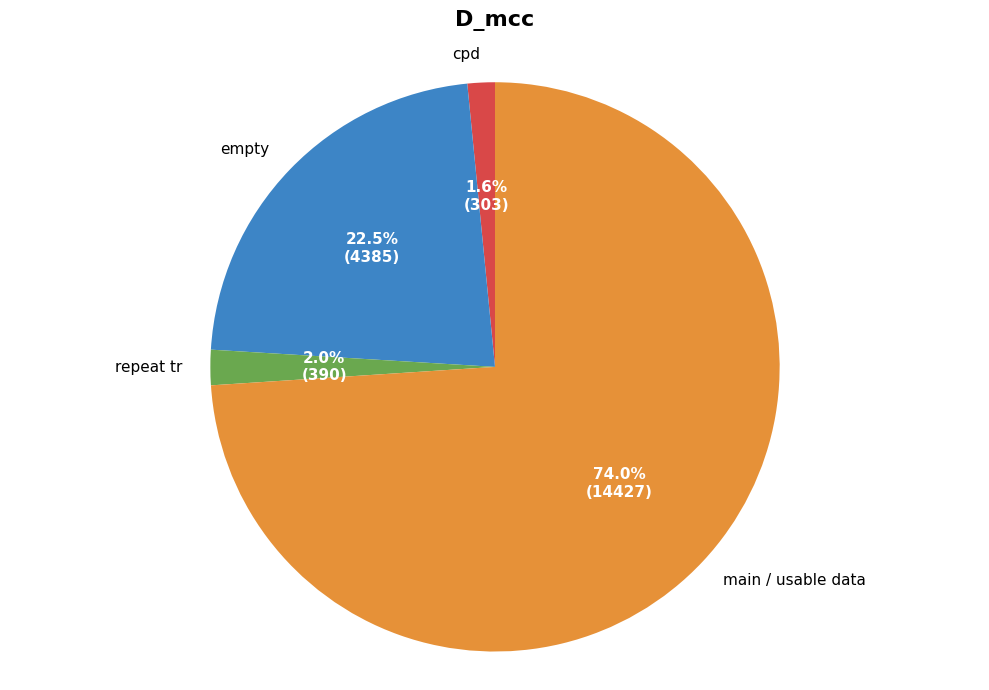

In [48]:
import matplotlib.pyplot as plt

# data
categories = ['cpd', 'empty', 'repeat tr', 'main / usable data']
values = [len(mccray_cpd), len(mccray_pure_empty), len(mccray_repeated), len(mccray)]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=['#d94848', '#3d85c6', '#6aa84f', '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title('D_mcc', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

plt.tight_layout()
